## Importação das Dependências e Configurações

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


## Análise Inicial dos Datasets

In [2]:
df_avl_suspeitas = pd.read_csv("../data/projeto_02_avaliacoes_suspeitas.csv")
df_vendas = pd.read_csv("../data/projeto_02_ecommerce_vendas.csv")
df_vendedores = pd.read_csv("../data/projeto_02_vendedores_perfil.csv")

Descrição dos Dados

In [3]:
df_vendedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vendedor_id          120 non-null    object 
 1   nome_loja            120 non-null    object 
 2   data_cadastro        120 non-null    object 
 3   cidade               120 non-null    object 
 4   estado               120 non-null    object 
 5   categoria_principal  120 non-null    object 
 6   total_vendas         120 non-null    int64  
 7   nota_media_loja      120 non-null    float64
 8   reclamacoes          120 non-null    int64  
 9   verificado           120 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 8.7+ KB


In [4]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pedido_id       8000 non-null   object 
 1   data_pedido     8000 non-null   object 
 2   hora_pedido     8000 non-null   object 
 3   vendedor_id     8000 non-null   object 
 4   categoria       8000 non-null   object 
 5   produto_id      8000 non-null   object 
 6   preco_unitario  8000 non-null   float64
 7   quantidade      8000 non-null   int64  
 8   valor_total     8000 non-null   float64
 9   frete           7767 non-null   float64
 10  estado_cliente  8000 non-null   object 
 11  status_pedido   8000 non-null   object 
 12  nota_avaliacao  5023 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 812.6+ KB


In [5]:
df_avl_suspeitas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   avaliacao_id        3000 non-null   object
 1   vendedor_id         3000 non-null   object
 2   comprador_id        3000 non-null   object
 3   data_avaliacao      3000 non-null   object
 4   data_criacao_conta  3000 non-null   object
 5   nota                3000 non-null   int64 
 6   ip_origem           3000 non-null   object
 7   texto_avaliacao     2668 non-null   object
dtypes: int64(1), object(7)
memory usage: 187.6+ KB


Transformando_dados de Dados

In [6]:
df_vendas['data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_hora_pedido'] = pd.to_datetime(df_vendas['hora_pedido'], format='%H:%M')

df_vendas['quantidade'] = df_vendas['quantidade'].astype("str").replace("nan", "0").astype("int")
df_vendas['preco_unitario'] = df_vendas['preco_unitario'].astype("float")
df_vendas['frete'] = df_vendas['frete'].fillna("-1").astype("float")

df_vendedores['data_cadastro_dt'] = pd.to_datetime(df_vendedores['data_cadastro'], format='%Y-%m-%d')

df_avl_suspeitas['data_avaliacao_dt'] = pd.to_datetime(df_avl_suspeitas['data_avaliacao'], format='%Y-%m-%d')
df_avl_suspeitas['data_criacao_conta_dt'] = pd.to_datetime(df_avl_suspeitas['data_criacao_conta'], format='%Y-%m-%d')
df_avl_suspeitas['texto_avaliacao'] = df_avl_suspeitas['texto_avaliacao'].fillna("Sem Comentário Explícito")


Investigações Base

0 - Validação da coluna "Verificado"

In [7]:
df_vendedores[['verificado']].value_counts(normalize='percent')

verificado
False         0.525
True          0.475
Name: proportion, dtype: float64

In [8]:
verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == True]['vendedor_id'].values)
nao_verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == False]['vendedor_id'].values)

print("Verificados")
print(verificados.size)
print(verificados)

print("--------------------------------")

print("Não Verificados")
print(nao_verificados.size)
print(nao_verificados)


Verificados
57
['VEND-0003' 'VEND-0006' 'VEND-0007' 'VEND-0009' 'VEND-0010' 'VEND-0015'
 'VEND-0016' 'VEND-0018' 'VEND-0019' 'VEND-0020' 'VEND-0022' 'VEND-0025'
 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0032' 'VEND-0041'
 'VEND-0047' 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060' 'VEND-0062'
 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0067' 'VEND-0071' 'VEND-0072'
 'VEND-0073' 'VEND-0074' 'VEND-0075' 'VEND-0077' 'VEND-0084' 'VEND-0085'
 'VEND-0086' 'VEND-0091' 'VEND-0092' 'VEND-0096' 'VEND-0098' 'VEND-0100'
 'VEND-0103' 'VEND-0107' 'VEND-0108' 'VEND-0109' 'VEND-0111' 'VEND-0112'
 'VEND-0116' 'VEND-0117' 'VEND-0118']
--------------------------------
Não Verificados
63
['VEND-0001' 'VEND-0002' 'VEND-0004' 'VEND-0005' 'VEND-0008' 'VEND-0011'
 'VEND-0012' 'VEND-0013' 'VEND-0014' 'VEND-0017' 'VEND-0021' 'VEND-0023'
 'VEND-0024' 'VEND-0030' 'VEND-0031' 'VEND-0033' 'VEND-0034' 'VEND-0035'
 'VEND-0036' 'VEND-

# 1. **Existem vendedores com padrão de vendas concentrado em horários atípicos** (madrugada, 2h-5h)? Quem são e qual o volume?

# Quantidade de Vendedores (Verificado x Não Verificado) por Hora do Pedido

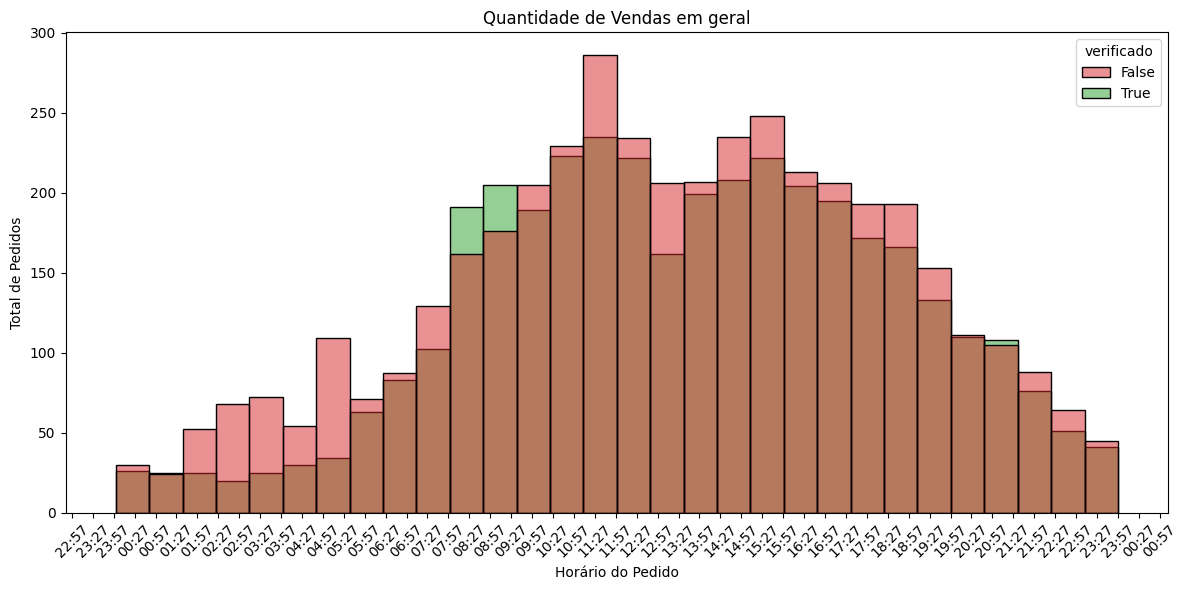

In [9]:
vendas_status_geral = df_vendas.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=vendas_status_geral,
    x='_hora_pedido',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title("Quantidade de Vendas em geral", fontsize=12)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

In [ ]:
# Vendedores com horáios atipicos (2h-5h)

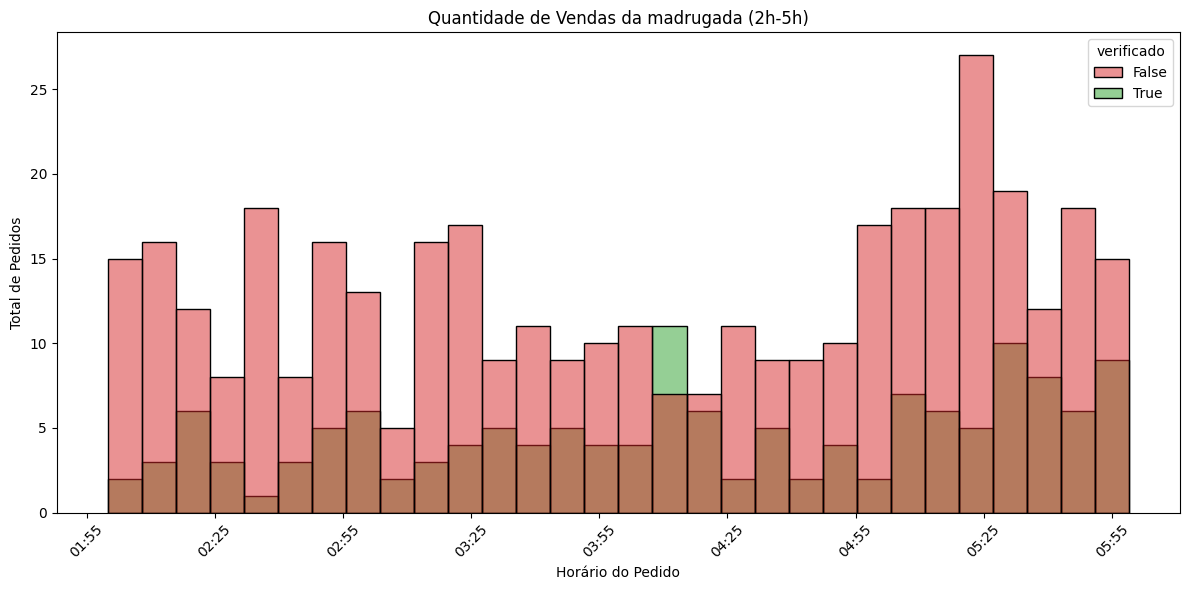

In [10]:

df_vendas_2_5 = df_vendas.query('_hora_pedido.dt.hour >= 2 and _hora_pedido.dt.hour <= 5')

vendas_status_2_5 = df_vendas_2_5.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=vendas_status_2_5,
    x='_hora_pedido',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title("Quantidade de Vendas da madrugada (2h-5h)")
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Vendedor')

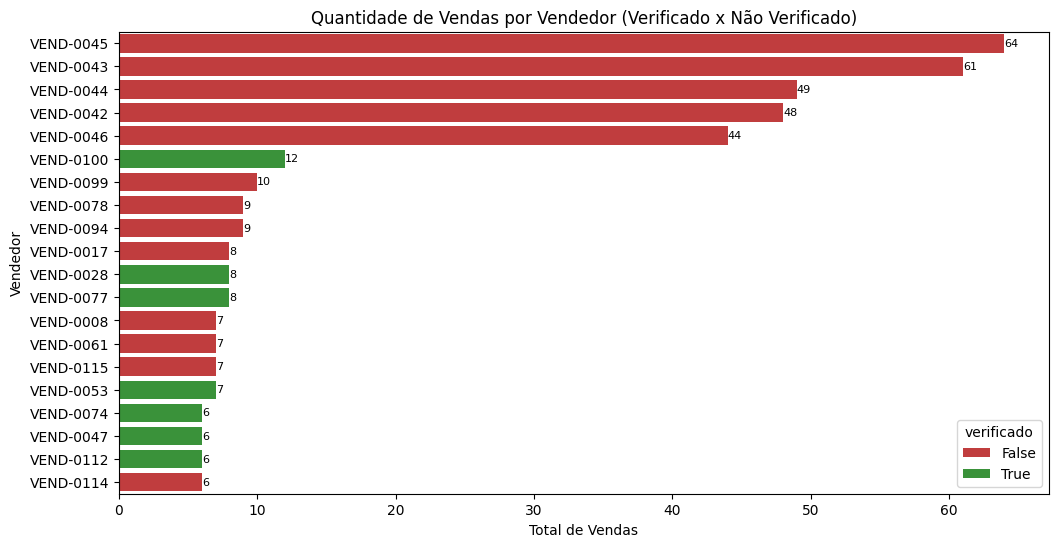

In [11]:
quantidade_vendas_por_vendedor = vendas_status_2_5.groupby(['vendedor_id', 'verificado']
                    )['quantidade'].sum().reset_index(name='total_vendas'
                    ).sort_values(by='total_vendas', ascending=False)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    quantidade_vendas_por_vendedor.head(20),
    x='total_vendas',
    y='vendedor_id',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.title("Quantidade de Vendas por Vendedor (Verificado x Não Verificado)")
plt.xlabel("Total de Vendas")
plt.ylabel("Vendedor")

# 2. **Há avaliações falsas?** Identifique padrões: contas criadas há poucos dias que avaliam com nota 5, IPs repetidos, textos idênticos.

Tempo de Criação de Conta

In [148]:
df_avl_suspeitas_info = df_avl_suspeitas.merge(df_vendedores, 
                                               on='vendedor_id', how='left')

df_avl_suspeitas_info['tempo_criacao_conta'] = (
    df_avl_suspeitas_info['data_avaliacao_dt'] - df_avl_suspeitas['data_criacao_conta_dt']
).dt.days

Casos Nota 5

In [149]:
df_nota5 = df_avl_suspeitas_info.query("nota == 5")

# Distribuição do Tempo de Criação da Conta

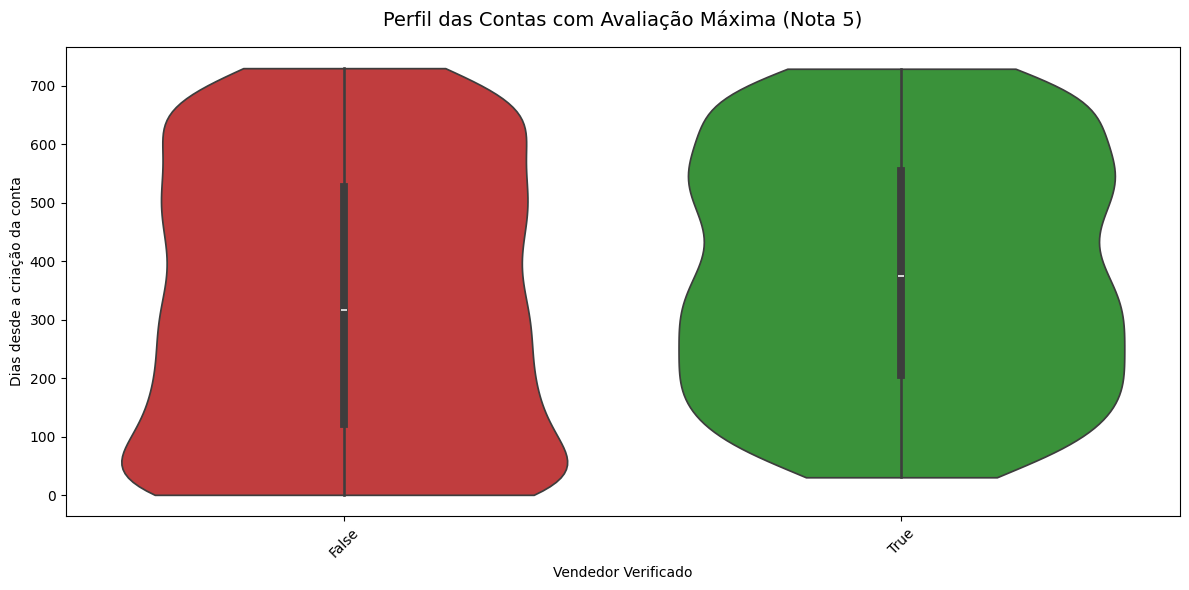

In [150]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_nota5, 
    x='verificado',
    y='tempo_criacao_conta', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.xticks(rotation=45)
plt.ylabel('Dias desde a criação da conta')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [151]:
df_nota5['verificado'].value_counts(normalize="percent")

verificado
False    0.533613
True     0.466387
Name: proportion, dtype: float64

<Axes: xlabel='verificado', ylabel='tempo_criacao_conta'>

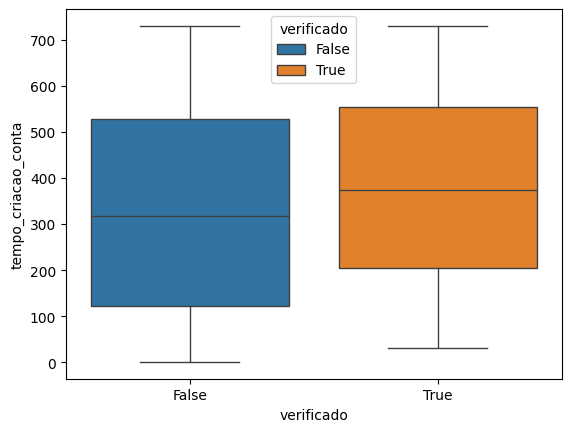

In [152]:
sns.boxplot(data=df_nota5, 
            y='tempo_criacao_conta', 
            x='verificado',
            hue='verificado')

Definição do Limite de Criação da Conta

In [153]:
df_nota5['tempo_criacao_conta'].value_counts().reset_index(name='count').sort_values(by='count', ascending=False).head(15)

,tempo_criacao_conta,count
0,1,18
1,6,17
2,4,13
3,2,12
4,5,11
5,3,9
6,548,6
7,195,6
8,475,5
9,258,5


In [154]:
df_nota5[df_nota5['verificado'] == False]['tempo_criacao_conta'].quantile([0.25, 0.5, 0.75])

0.25    122.0
0.50    317.0
0.75    527.5
Name: tempo_criacao_conta, dtype: float64

In [155]:
df_nota5[df_nota5['verificado'] == True]['tempo_criacao_conta'].quantile([0.25, 0.5, 0.75])

0.25    205.5
0.50    375.0
0.75    554.0
Name: tempo_criacao_conta, dtype: float64

In [156]:
limite_principal = df_nota5[df_nota5['verificado'] == False]['tempo_criacao_conta'].quantile(0.25)

# Validação de Ips

Análise de IP

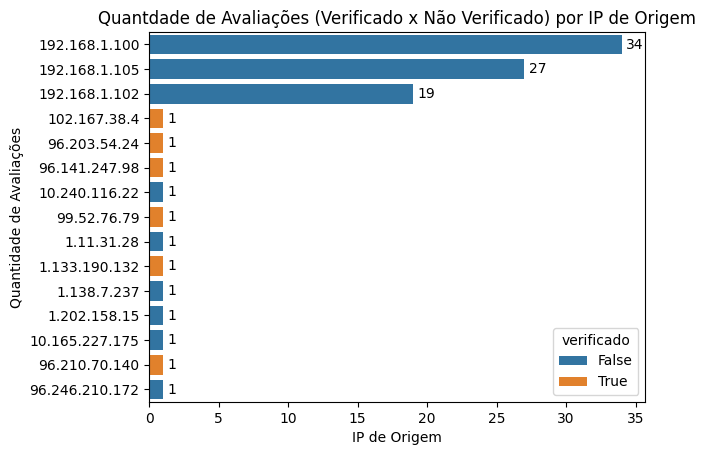

In [157]:
df_ip_origem = df_nota5.groupby(
    ['ip_origem', 'verificado']
)['avaliacao_id'].size().reset_index(name='contagem_avaliacoes').sort_values(by='contagem_avaliacoes', ascending=False)

ax = sns.barplot(
    data=df_ip_origem.head(15),
    y='ip_origem',
    x='contagem_avaliacoes', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Avaliações (Verificado x Não Verificado) por IP de Origem")
plt.xlabel("IP de Origem")
plt.ylabel("Quantidade de Avaliações")
plt.show()

Análise de Rede/Subrede

In [176]:
df_nota5['rede'] = df_nota5['ip_origem'].str.split(".").str[0:1].str.join(".")
df_nota5['subrede'] = df_nota5['ip_origem'].str.split(".").str[0:2].str.join(".")
df_nota5['subrede_local'] = df_nota5['ip_origem'].str.split(".").str[0:3].str.join(".")


C:\Users\rpf97\AppData\Local\Temp\ipykernel_4904\1169564160.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nota5['rede'] = df_nota5['ip_origem'].str.split(".").str[0:1].str.join(".")
C:\Users\rpf97\AppData\Local\Temp\ipykernel_4904\1169564160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nota5['subrede'] = df_nota5['ip_origem'].str.split(".").str[0:2].str.join(".")
C:\Users\rpf97\AppData\Local\Temp\ipykernel_4904\1169564160.py:3: SettingWithCopyWarning: 
A value is trying to be set on a cop

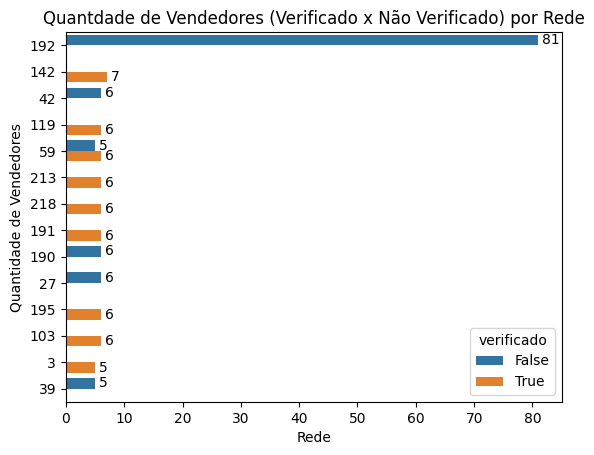

In [177]:
df_ip_rede = df_nota5.groupby(
    ['rede', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_vendedores').sort_values(by='contagem_vendedores', ascending=False)

ax = sns.barplot(
    data=df_ip_rede.head(15),
    y='rede',
    x='contagem_vendedores', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por Rede")
plt.xlabel("Rede")
plt.ylabel("Quantidade de Vendedores")
plt.show()

OBS: Não funcionaria porque é um conjunto muito mais amplo

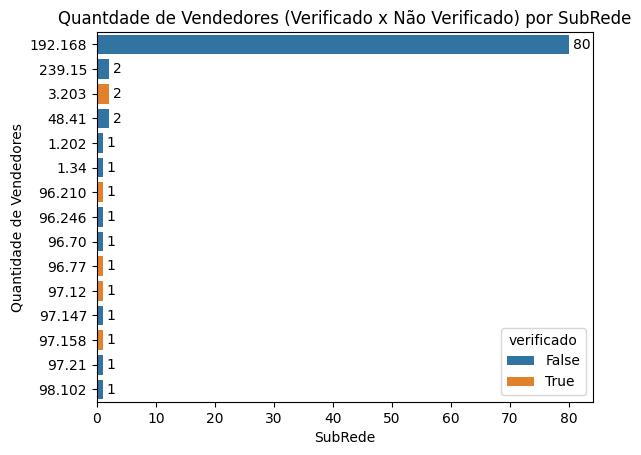

In [178]:
df_ip_subrede = df_nota5.groupby(
    ['subrede', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_vendedores').sort_values(by='contagem_vendedores', ascending=False)

ax = sns.barplot(
    data=df_ip_subrede.head(15),
    y='subrede',
    x='contagem_vendedores', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por SubRede")
plt.xlabel("SubRede")
plt.ylabel("Quantidade de Vendedores")
plt.show()

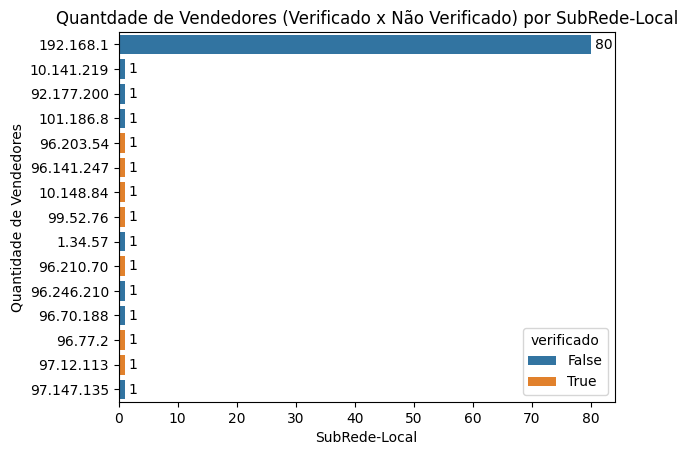

In [179]:
df_ip_subrede_local = df_nota5.groupby(
    ['subrede_local', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_vendedores').sort_values(by='contagem_vendedores', ascending=False)

ax = sns.barplot(
    data=df_ip_subrede_local.head(15),
    y='subrede_local',
    x='contagem_vendedores', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por SubRede-Local")
plt.xlabel("SubRede-Local")
plt.ylabel("Quantidade de Vendedores")
plt.show()

Quantidade de textos mais comuns por vendedor

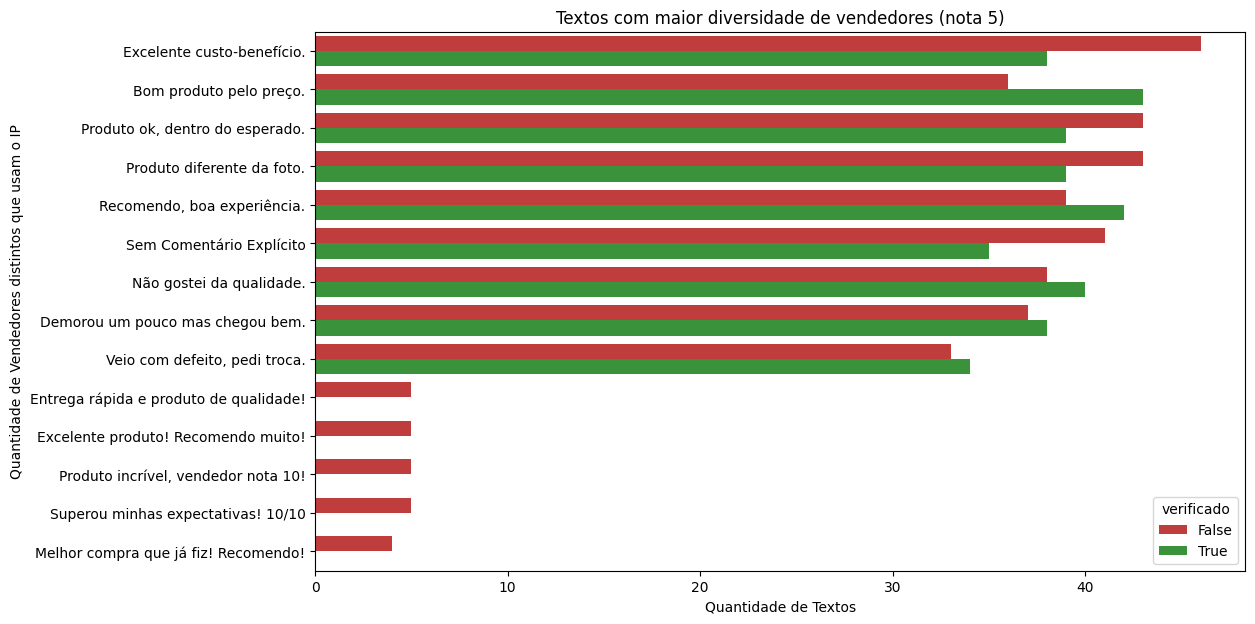

In [180]:
texto_comum_vendedor = df_nota5.groupby(['texto_avaliacao', 'verificado'])['vendedor_id'].nunique(
                        ).reset_index(name='quantidade_vendedores').sort_values(by='quantidade_vendedores', ascending=False
                        ).query("quantidade_vendedores > 1")


plt.figure(figsize=(12, 7))

sns.barplot(
    data=texto_comum_vendedor,
    x='quantidade_vendedores',
    y='texto_avaliacao',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)

plt.title('Textos com maior diversidade de vendedores (nota 5)')
plt.xlabel('Quantidade de Textos')
plt.ylabel('Quantidade de Vendedores distintos que usam o IP')
plt.show()

Quantidade de Categorias por Vendedor (Verificado x Não Verificado)

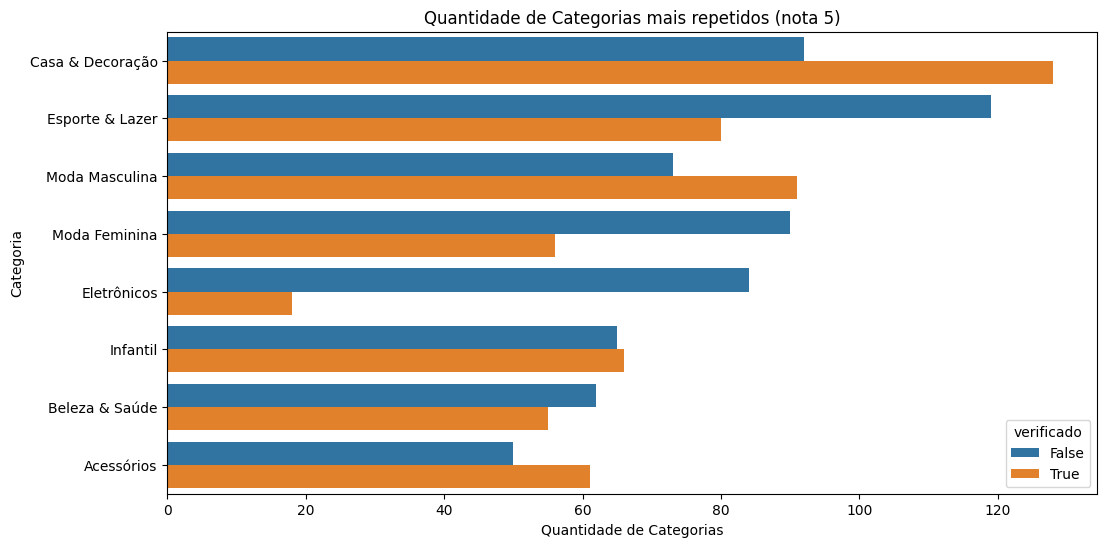

In [164]:
def_quant_categorias = df_avl_suspeitas_info.query("nota == 5").groupby(
    ['categoria_principal', 'verificado']
).size().reset_index(name='contagem_categorial_principal').sort_values(by='contagem_categorial_principal', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    def_quant_categorias,
    x='contagem_categorial_principal',
    y='categoria_principal',
    hue='verificado'
)

plt.title('Quantidade de Categorias mais repetidos (nota 5)')
plt.xlabel("Quantidade de Categorias")
plt.ylabel("Categoria")
plt.show()

Vendedores Suspeitos

In [183]:
df_nota5['possui_ips_repetidos'] = (
    df_nota5.groupby(['subrede', 'verificado'])['vendedor_id'].transform("size") > 1
)

C:\Users\rpf97\AppData\Local\Temp\ipykernel_4904\1226311533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nota5['possui_ips_repetidos'] = (


In [181]:
df_nota5['possui_textos_repetidos'] = (
    df_nota5.groupby(['texto_avaliacao', 'verificado'])['vendedor_id'].transform("nunique") > 1
)

C:\Users\rpf97\AppData\Local\Temp\ipykernel_4904\459057325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nota5['possui_textos_repetidos'] = (


In [185]:
pd.unique(df_nota5['possui_textos_repetidos'])

array([ True])

In [188]:
df_nota5['score'] = (
                    (df_nota5['possui_ips_repetidos'])
                    + (df_nota5['possui_textos_repetidos']) 
                    + ((df_nota5['nota'] == 5).astype("int"))
                    + ((df_avl_suspeitas['tempo_criacao_conta'] <= 10).astype("int")*5)
                )

KeyError: 'tempo_criacao_conta'

## 3. **Os vendedores suspeitos compartilham características em comum?** Cruze com o cadastro: data de cadastro próxima, mesma cidade, nomes similares, não verificados.

## 4. **Qual o impacto financeiro** das vendas dos vendedores suspeitos? Quanto representam do faturamento total?

## 5. **A taxa de cancelamento/devolução** dos vendedores suspeitos é diferente dos demais?

In [ ]:
# Calculo Percentual dos produtos Devolvidos

## 6. **Construa um "score de risco"** baseado nos indicadores encontrados. Quais critérios compõem esse score?


## 7. **Proponha regras automáticas** para detectar fraudes futuras baseadas nos padrões descobertos.


Regras

1 O Horário é Irrelevante até o Momento

2 - A Categoria do Produto é irrelevante até o Momento

3 - Somente considerar a Cidade se progredir com o tempo

4 - Avaliar nos Graficos os Ips de Origem se baseando em sua subrede
para verificar padrões suspeitos